In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

def lognormal_approx_reliability(mean_sinr, std_dev_sinr, rel_th):
	s_R = math.sqrt(math.log((std_dev_sinr**2)/(mean_sinr**2) + 1))
	m_R = math.log(mean_sinr) - 0.5 * s_R**2
	cdf = 0.5 + 0.5 * math.erf((math.log(rel_th) - m_R) / (s_R * math.sqrt(2)))
	return 1 - cdf

def sgolay_filter_smooth(data, window_length=11, polyorder=2):
	'''
	Applies Savitzky-Golay filter to smoothen the data.
	The smoothing is applied along horizontal distance, for each combination of height, usi and mcs.
	'''
	# Sort by USI, MCS, Height, Horizontal_Distance first to make sure that the data is in order
	data = data.sort_values(by=["UAV_Sending_Interval", "Bitrate", "Height", "Horizontal_Distance"])
	# Apply Savitzky-Golay filter
	heights = data["Height"].unique()
	usi_values = data["UAV_Sending_Interval"].unique()
	bitrate_values = data["Bitrate"].unique()
	for h in heights:
		for usi in usi_values:
			for bitrate in bitrate_values:
				mask = (data["Height"] == h) & (data["UAV_Sending_Interval"] == usi) & (data["Bitrate"] == bitrate)
				data.loc[mask, "Logit_Reliability"] = savgol_filter(data.loc[mask, "Logit_Reliability"], window_length=window_length, polyorder=polyorder)
	return data

def create_logits(df):
	'''
	Takes a df with the column 'Reliability' and creates logits for regression.
	Clips the logits to avoid inf values.
	'''
	df_out = df.copy()
	eps = 1e-6
	df_out['Reliability'] = df_out['Reliability'].apply(lambda x: min(max(x, eps), 1 - eps))
	df_out['Logit_Reliability'] = df_out['Reliability'].apply(lambda x: math.log(x / (1 - x)))
	return df_out


In [25]:
# SINR_TH = 0.00106802  # downlink (-29.7142 dB)
SINR_TH = 0.0104514  # uplink (-19.8083 dB)
# SINR_TH = 0.0743382  # video (-11.2879 dB)
# SINR_TH = 2

height = 75  # meters
usi = 20
bitrate = 13

test_data_file = "/media/research-student/KingstonSSD/FANET_Dataset/Dataset_NP100000_DJISpark/complete_testing_dmax_dataset/data_processed_complete/Downlink_Reliability.csv"
data_df = pd.read_csv(test_data_file)
data_df["Reliability"] = data_df["Num_Reliable"] / (data_df["Num_Reliable"] + data_df["Num_Delay_Excd"] + data_df["Num_Fail_Other"])
data = data_df.loc[(data_df['Height'] == height) & (data_df['UAV_Sending_Interval'] == usi) & (data_df['Bitrate'] == bitrate)]
# data["Lognormal_Reliability"] = data.apply(lambda x: lognormal_approx_reliability(x["Mean_SINR"], x["Std_Dev_SINR"], SINR_TH), axis=1)


In [7]:
data_df

,Unnamed: 0.1,Horizontal_Distance,Height,UAV_Sending_Interval,Bitrate,Mean_SINR,Std_Dev_SINR,Num_Reliable,Num_Delay_Excd,Num_Fail_Other,Unnamed: 0,Modulation,Reliability
0,0,0.0,75,10.0,6.5,718.555932,297.738231,6,24310,75684,0.0,BPSK,0.00006
1,0,5.0,75,10.0,6.5,701.276207,293.664326,7,24981,75012,NaN,NaN,0.00007
2,1,10.0,75,10.0,6.5,678.518792,287.202555,5,25166,74829,1.0,BPSK,0.00005
3,1,15.0,75,10.0,6.5,651.035592,278.603793,7,25094,74899,NaN,NaN,0.00007
4,2,20.0,75,10.0,6.5,619.770457,268.210488,4,24642,75354,2.0,BPSK,0.00004
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30971,15613,580.0,285,100.0,65.0,4.577175,2.947570,0,0,100000,4317.0,QAM64,0.00000
30972,15358,585.0,285,100.0,65.0,4.486460,2.902625,0,0,100000,NaN,NaN,0.00000
30973,15614,590.0,285,100.0,65.0,4.397911,2.858614,0,0,100000,4318.0,QAM64,0.00000
30974,15359,595.0,285,100.0,65.0,4.311469,2.815514,0,0,100000,NaN,NaN,0.00000


## Plot Physical Layer Reliability vs Horizontal Distance

In [ ]:
# Plot Lognormal_Reliability vs Distance
plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 14})
plt.plot(data["Horizontal_Distance"], data["Lognormal_Reliability"], label="Lognormal Approximation", color='blue')
# plt.xlabel("Horizontal Distance (m)")
# plt.ylabel("1 - CDF of SINR at Threshold")
plt.ylim(-0.01, 1.01)

## Plot Reliability vs Horizontal Distance

Text(0.5, 0, 'Horizontal Distance (m)')

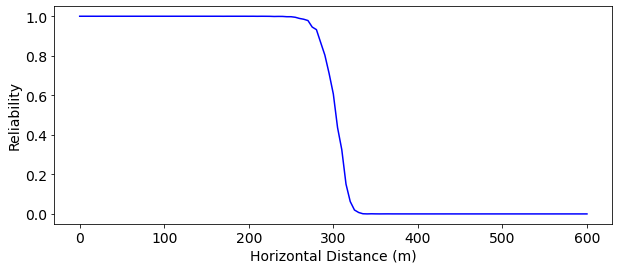

In [27]:
plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 14})
plt.plot(data["Horizontal_Distance"], data["Reliability"], label="Reliability", color='blue')
plt.ylabel("Reliability")
plt.xlabel("Horizontal Distance (m)")

## Plot Mean and Std Dev of SINR vs Horizontal Distance

/tmp/ipykernel_121382/3564271870.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Mean_SINR_dB"] = 10 * np.log10(data["Mean_SINR"])
/tmp/ipykernel_121382/3564271870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Std_Dev_SINR_dB"] = 10 * np.log10(data["Std_Dev_SINR"])


Text(0, 0.5, 'Std Dev SINR (dB)')

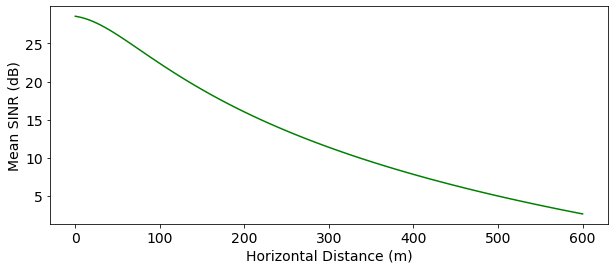

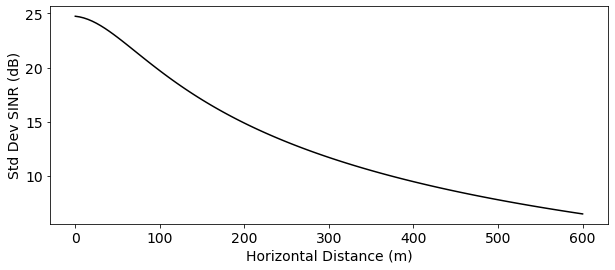

In [37]:
# Convert Mean and Std Dev SINR to logarithmic scale (dB) for plotting
data["Mean_SINR_dB"] = 10 * np.log10(data["Mean_SINR"])
data["Std_Dev_SINR_dB"] = 10 * np.log10(data["Std_Dev_SINR"])

plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 14})
plt.plot(data["Horizontal_Distance"], data["Mean_SINR_dB"], label="Mean SINR", color='green')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Mean SINR (dB)")

plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 14})
plt.plot(data["Horizontal_Distance"], data["Std_Dev_SINR_dB"], label="Std Dev SINR", color='black')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Std Dev SINR (dB)")

## Plot Logits of Reliability

Text(0, 0.5, 'Logit of Reliability')

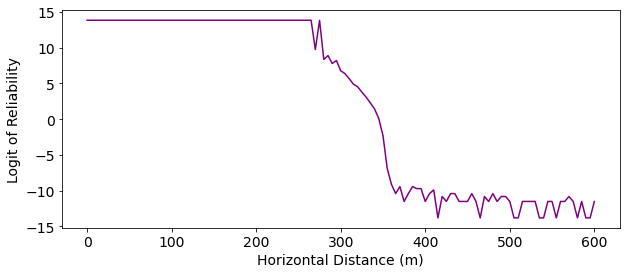

In [17]:
def create_logits(df):
	'''
	Takes a df with the column 'Reliability' and creates logits for regression.
	Clips the logits to avoid inf values.
	'''
	df_out = df.copy()
	eps = 1e-6
	df_out['Reliability'] = df_out['Reliability'].apply(lambda x: min(max(x, eps), 1 - eps))
	df_out['Logit_Reliability'] = df_out['Reliability'].apply(lambda x: math.log(x / (1 - x)))
	return df_out

data = create_logits(data)

plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 14})
plt.plot(data["Horizontal_Distance"], data["Logit_Reliability"], label="Logits", color='purple')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Logit of Reliability")

Text(0, 0.5, 'Logit of Reliability')

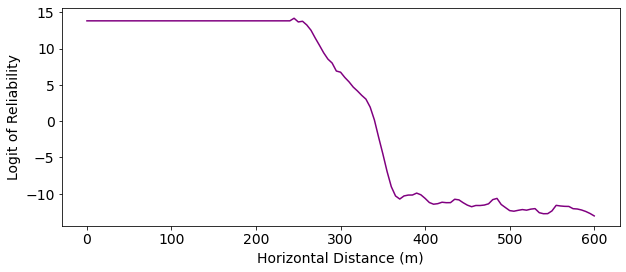

In [10]:
from scipy.signal import savgol_filter

data = create_logits(data)

# Let's smoothen out the data first
data["Logit_Reliability"] = savgol_filter(data["Logit_Reliability"], window_length=10, polyorder=2)

plt.figure(figsize=(10, 4))
plt.rcParams.update({'font.size': 14})
plt.plot(data["Horizontal_Distance"], data["Logit_Reliability"], label="Logits", color='purple')
plt.xlabel("Horizontal Distance (m)")
plt.ylabel("Logit of Reliability")